# Actividad 6 — Desafios en la Integracion al Data Warehouse

**Proyecto:** Prediccion de Produccion de Limon en el Peru  
**Pipeline:** Fase 1 — Ingenieria de Datos  

---

## Objetivo
Unir las 4 fuentes limpias en un unico dataset integrado resolviendo los desafios de granularidad, cobertura geografica y temporal. El resultado es el `dataset_integrado.csv` que alimentara el Star Schema.

## Los 4 desafios de integracion
| Desafio | Descripcion | Solucion |
|---------|-------------|----------|
| Granularidad | INDECI tiene eventos individuales; Agraria tiene noticias individuales | Agregar a mensual por provincia |
| Cobertura geografica | Cada fuente cubre diferentes provincias | Esqueleto basado en provincias MIDAGRI |
| Cobertura temporal | INDECI solo hasta 2023-02; otras hasta 2025-08 | LEFT JOIN + relleno con 0 |
| Nombres geograficos | Posibles inconsistencias residuales entre fuentes | Verificacion y normalizacion cruzada |

## Regla de esta actividad
> El dataset integrado debe tener exactamente **una fila por combinacion `(fecha_evento, departamento, provincia)`**. Si hay duplicados, el merge fallo.


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']

def normalizar(t):
    if not isinstance(t, str): return ''
    resultado = []
    for c in t.upper():
        if c == 'N' and False: resultado.append('N')
        else:
            c_norm = unicodedata.normalize('NFKD', c).encode('ASCII','ignore').decode('utf-8')
            resultado.append(c_norm if c_norm else c)
    return ''.join(resultado).strip()

os.makedirs(OUTPUT['integracion'], exist_ok=True)
print('Config cargado OK | Raiz:', os.getcwd())
print('Carpeta de salida:', OUTPUT['integracion'])


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-
Carpeta de salida: pipeline/output/06_integracion/


---
# 1. Carga de los Datasets Limpios


In [2]:
# Cargar los 4 datasets limpios de la Actividad 5
df_midagri = pd.read_csv(OUTPUT['limpieza'] + 'midagri_limon_clean.csv')
df_indeci  = pd.read_csv(OUTPUT['limpieza'] + 'indeci_eventos_clean.csv', low_memory=False)
df_nasa    = pd.read_csv(OUTPUT['limpieza'] + 'nasa_long_clean.csv', low_memory=False)
df_agraria = pd.read_csv(OUTPUT['limpieza'] + 'agraria_mensual.csv')

print('Datasets cargados:')
print(f'  MIDAGRI:  {df_midagri.shape} | cols: {df_midagri.columns.tolist()}')
print(f'  INDECI:   {df_indeci.shape}  | cols: {df_indeci.columns.tolist()[:8]}')
print(f'  NASA:     {df_nasa.shape}    | cols: {df_nasa.columns.tolist()}')
print(f'  AGRARIA:  {df_agraria.shape} | cols: {df_agraria.columns.tolist()}')


Datasets cargados:
  MIDAGRI:  (3942, 6) | cols: ['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg']
  INDECI:   (13487, 11)  | cols: ['fecha_evento', 'departamento', 'provincia', 'fenomeno', 'anho', 'mes', 'personas_afectadas', 'personas_damnificadas']
  NASA:     (6120, 13)    | cols: ['departamento', 'provincia', 'anho', 'mes', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M', 'fecha_evento']
  AGRARIA:  (58, 2) | cols: ['fecha_evento', 'n_noticias']


---
# 2. Desafio 1 — Verificacion de Nombres Geograficos

Antes del merge, verificar que los nombres de departamento y provincia son consistentes entre MIDAGRI, INDECI y NASA.


In [3]:
# Obtener conjuntos de departamentos por fuente
dptos_midagri = set(df_midagri['departamento'].str.upper().str.strip().unique())
dptos_nasa    = set(df_nasa['departamento'].str.upper().str.strip().unique())
dptos_indeci  = set(df_indeci['departamento'].str.upper().str.strip().unique()) if 'departamento' in df_indeci.columns else set()

print('=== DEPARTAMENTOS POR FUENTE ===')
print(f'MIDAGRI: {len(dptos_midagri)} departamentos')
print(f'NASA:    {len(dptos_nasa)} departamentos')
print(f'INDECI:  {len(dptos_indeci)} departamentos')
print()

# Departamentos en MIDAGRI que NO estan en NASA
solo_midagri = dptos_midagri - dptos_nasa
solo_nasa    = dptos_nasa - dptos_midagri
en_ambos     = dptos_midagri & dptos_nasa

print(f'En MIDAGRI y NASA: {len(en_ambos)}')
print(f'Solo en MIDAGRI (no en NASA): {len(solo_midagri)}')
if solo_midagri: print(f'  {sorted(solo_midagri)}')
print(f'Solo en NASA (no en MIDAGRI): {len(solo_nasa)}')
if solo_nasa: print(f'  {sorted(solo_nasa)}')

# Normalizar para el merge
for df, nombre in [(df_midagri,'MIDAGRI'),(df_nasa,'NASA'),(df_indeci,'INDECI')]:
    if 'departamento' in df.columns:
        df['departamento'] = df['departamento'].apply(normalizar)
    if 'provincia' in df.columns:
        df['provincia'] = df['provincia'].apply(normalizar)

print()
print('Normalizacion aplicada a todas las fuentes.')


=== DEPARTAMENTOS POR FUENTE ===
MIDAGRI: 23 departamentos
NASA:    23 departamentos
INDECI:  25 departamentos

En MIDAGRI y NASA: 23
Solo en MIDAGRI (no en NASA): 0
Solo en NASA (no en MIDAGRI): 0

Normalizacion aplicada a todas las fuentes.


### Interpretacion

**Que muestra:** Los departamentos presentes en cada fuente y si hay inconsistencias de nombres que impediran el JOIN.

**Implicacion para el pipeline:** Si hay departamentos en MIDAGRI que no estan en NASA, esas filas tendran NaN en las variables climaticas despues del merge. Se rellenaran con la media de la provincia en el paso de relleno.

**Implicacion para el modelo:** La cobertura geografica del dataset integrado determina cuantas series temporales completas tendra el LSTM-Attention para entrenarse.


## Grafico 1 — Cobertura geografica por fuente


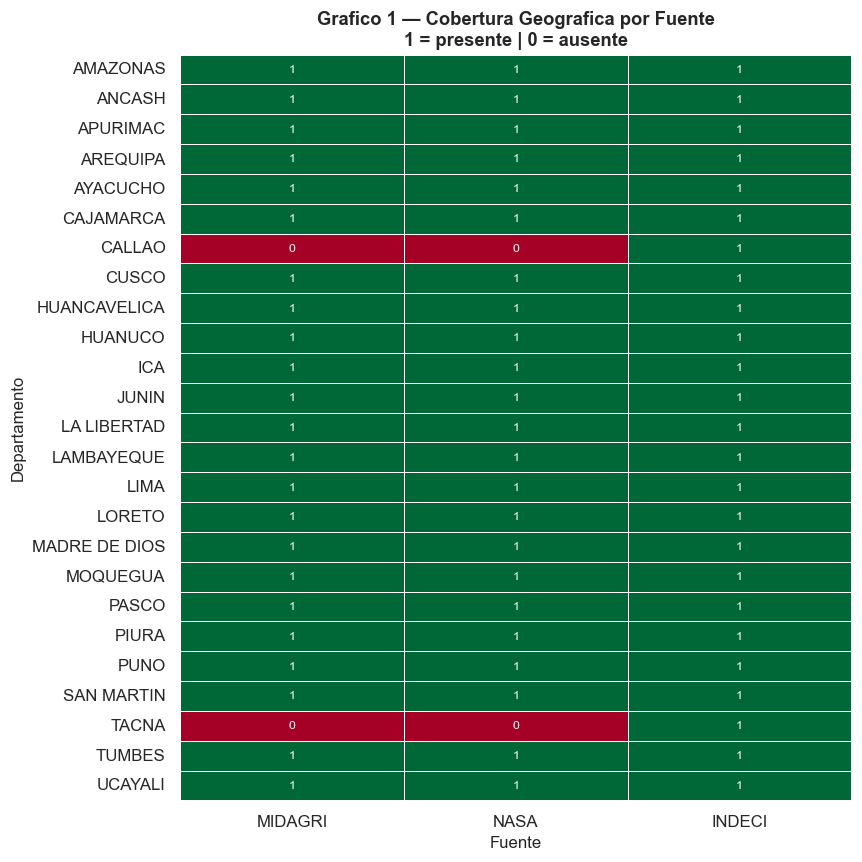

Guardado: pipeline/output/03_eda/act06_g1_cobertura_geo.png


In [4]:
# Recalcular despues de normalizacion
dptos_midagri = set(df_midagri['departamento'].unique())
dptos_nasa    = set(df_nasa['departamento'].unique())
dptos_indeci  = set(df_indeci['departamento'].unique()) if 'departamento' in df_indeci.columns else set()

todos_dptos = sorted(dptos_midagri | dptos_nasa | dptos_indeci)

# Matriz de presencia
presencia = pd.DataFrame({
    'MIDAGRI': [1 if d in dptos_midagri else 0 for d in todos_dptos],
    'NASA':    [1 if d in dptos_nasa    else 0 for d in todos_dptos],
    'INDECI':  [1 if d in dptos_indeci  else 0 for d in todos_dptos],
}, index=todos_dptos)

fig, ax = plt.subplots(figsize=(8, max(8, len(todos_dptos)*0.3)))
sns.heatmap(presencia, annot=True, fmt='d', cmap='RdYlGn',
            ax=ax, linewidths=0.5, cbar=False,
            annot_kws={'size': 8})
ax.set_title('Grafico 1 — Cobertura Geografica por Fuente\n'
             '1 = presente | 0 = ausente',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fuente', fontsize=11)
ax.set_ylabel('Departamento', fontsize=11)
plt.tight_layout()
g = OUTPUT['eda'] + 'act06_g1_cobertura_geo.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** Que departamentos tiene cada fuente. Verde = presente, Rojo = ausente. Los departamentos con 1 en las 3 fuentes tendran datos completos en el dataset integrado.

**Implicacion para el pipeline:** Los departamentos con 0 en alguna fuente tendran NaN en las variables de esa fuente despues del merge. La estrategia de relleno determinara como se manejan esos casos.

**Implicacion para el modelo:** Solo los departamentos con cobertura en las 3 fuentes principales (MIDAGRI, NASA, INDECI) tendran series temporales completas para el entrenamiento del LSTM-Attention.


---
# 3. Desafio 2 — Agregacion INDECI a Granularidad Mensual

INDECI tiene un registro por evento de emergencia. Necesitamos agregarlo a nivel mensual por provincia para el merge.


In [5]:
# Verificar columnas disponibles en INDECI
print('Columnas INDECI:', df_indeci.columns.tolist())
print(f'Registros INDECI: {len(df_indeci):,}')
print()

# Columnas de impacto disponibles
cols_impacto = {}
for col_orig, col_dest in [
    ('personas_afectadas','total_afectados'),
    ('safecta','total_afectados'),
    ('has_cultivo_perdidas','has_cultivo_perdidas'),
    ('sareacul_1','has_cultivo_perdidas'),
]:
    if col_orig in df_indeci.columns:
        cols_impacto[col_orig] = col_dest
        break

# Construir diccionario de agregacion
agg_dict = {'fenomeno': 'count'}  # contar emergencias
for col_orig, col_dest in cols_impacto.items():
    agg_dict[col_orig] = 'sum'

# Agregar por fecha_evento, departamento, provincia
df_indeci_mensual = (
    df_indeci.dropna(subset=['fecha_evento','departamento'])
    .groupby(['fecha_evento','departamento','provincia'])
    .agg(agg_dict)
    .reset_index()
)

# Renombrar columnas
rename = {'fenomeno': 'num_emergencias'}
rename.update({k: v for k, v in cols_impacto.items()})
df_indeci_mensual = df_indeci_mensual.rename(columns=rename)

print(f'INDECI agregado: {df_indeci_mensual.shape}')
print(f'Meses unicos: {df_indeci_mensual["fecha_evento"].nunique()}')
print(f'Rango: {df_indeci_mensual["fecha_evento"].min()} -> {df_indeci_mensual["fecha_evento"].max()}')
display(df_indeci_mensual.head(5))


Columnas INDECI: ['fecha_evento', 'departamento', 'provincia', 'fenomeno', 'anho', 'mes', 'personas_afectadas', 'personas_damnificadas', 'personas_fallecidas', 'has_cultivo_afectadas', 'has_cultivo_perdidas']
Registros INDECI: 13,487

INDECI agregado: (2953, 5)
Meses unicos: 26
Rango: 2021-01 -> 2023-02


,fecha_evento,departamento,provincia,num_emergencias,total_afectados
0,2021-01,AMAZONAS,BAGUA,2,93.0
1,2021-01,AMAZONAS,BONGARA,1,9.0
2,2021-01,AMAZONAS,CHACHAPOYAS,2,3.0
3,2021-01,AMAZONAS,CONDORCANQUI,2,5.0
4,2021-01,AMAZONAS,LUYA,3,2.0


### Interpretacion

**Que muestra:** La transformacion de INDECI de nivel evento a nivel mensual-provincial. Cada fila ahora representa el total de emergencias en una provincia en un mes.

**Implicacion para el pipeline:** La agregacion mensual es necesaria para que INDECI tenga la misma granularidad que MIDAGRI y NASA. Sin esta agregacion, el merge generaria multiples filas por mes-provincia.

**Implicacion para el modelo:** La variable `num_emergencias` representa el numero de eventos hidrometeorologicos en una provincia en un mes, que es la señal relevante para predecir el impacto en la produccion.


---
# 4. Desafio 3 — Construccion del Esqueleto Temporal

El esqueleto garantiza que el dataset final tenga una fila por cada combinacion mes × provincia, incluso si no hubo produccion o emergencias ese mes.


Meses en el pipeline: 56 (2021-01 a 2025-08)
Provincias productoras de limon: 105
Filas esperadas en el dataset integrado: 5,880
Esqueleto generado: (5880, 3)


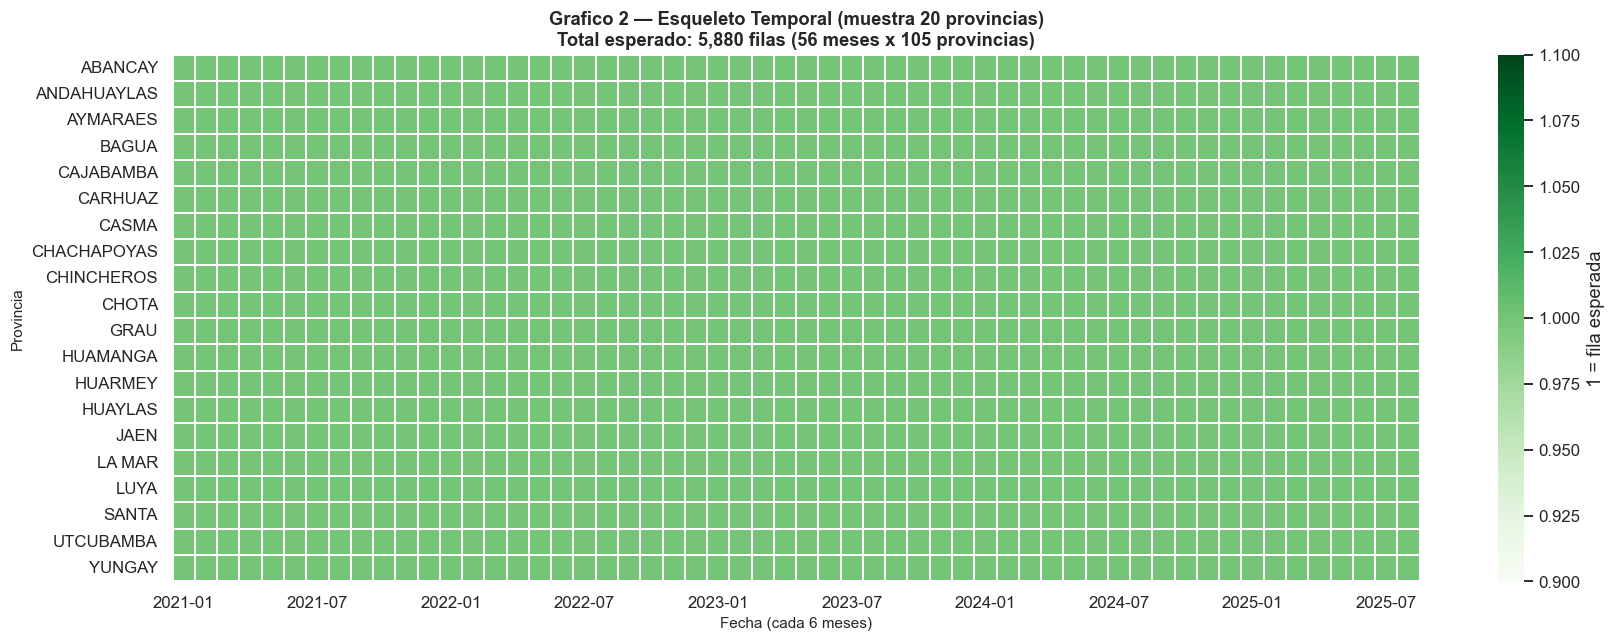

Guardado: pipeline/output/03_eda/act06_g2_esqueleto.png


In [6]:
# Rango temporal del pipeline
fechas = pd.date_range(
    start=f'{CONFIG["anho_inicio"]}-01-01',
    end=f'{CONFIG["anho_fin"]}-{CONFIG["mes_fin"]:02d}-01',
    freq='MS'
).strftime('%Y-%m').tolist()

# Provincias de MIDAGRI (las que producen limon)
provincias = df_midagri[['departamento','provincia']].drop_duplicates()

# Producto cartesiano: todos los meses x todas las provincias
skeleton_rows = []
for fecha in fechas:
    for _, row in provincias.iterrows():
        skeleton_rows.append({
            'fecha_evento': fecha,
            'departamento': row['departamento'],
            'provincia': row['provincia']
        })
df_skeleton = pd.DataFrame(skeleton_rows)

n_meses = len(fechas)
n_provincias = len(provincias)
n_esperado = n_meses * n_provincias

print(f'Meses en el pipeline: {n_meses} ({fechas[0]} a {fechas[-1]})')
print(f'Provincias productoras de limon: {n_provincias}')
print(f'Filas esperadas en el dataset integrado: {n_esperado:,}')
print(f'Esqueleto generado: {df_skeleton.shape}')

# Grafico G2: esqueleto temporal
prov_sample = provincias.head(20)['provincia'].tolist()
skeleton_sample = df_skeleton[df_skeleton['provincia'].isin(prov_sample)]
pivot_skel = skeleton_sample.groupby(['fecha_evento','provincia']).size().unstack(fill_value=0)
pivot_bool = (pivot_skel > 0).astype(int)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_bool.T, cmap='Greens', ax=ax,
            xticklabels=6, linewidths=0.1,
            cbar_kws={'label': '1 = fila esperada'})
ax.set_title('Grafico 2 — Esqueleto Temporal (muestra 20 provincias)\n'
             f'Total esperado: {n_esperado:,} filas ({n_meses} meses x {n_provincias} provincias)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fecha (cada 6 meses)', fontsize=10)
ax.set_ylabel('Provincia', fontsize=10)
plt.tight_layout()
g = OUTPUT['eda'] + 'act06_g2_esqueleto.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** El esqueleto temporal — todas las combinaciones mes × provincia que debe tener el dataset integrado. Cada celda verde es una fila esperada.

**Por que es necesario:** Sin el esqueleto, el dataset solo tendria filas donde hubo produccion registrada. Los meses sin produccion (valor 0) no existirian, lo que romperia la continuidad de las series temporales.

**Implicacion para el modelo:** El LSTM-Attention necesita series temporales continuas sin huecos. El esqueleto garantiza que cada provincia tiene exactamente 56 meses de datos (2021-01 a 2025-08), incluso si algunos tienen produccion = 0.


---
# 5. Desafio 4 — LEFT JOINs en Cascada

Unir las 4 fuentes al esqueleto usando LEFT JOINs. El esqueleto es la base — si una fuente no tiene datos para un mes-provincia, quedara NaN (que se rellenara en el siguiente paso).


In [7]:
# ── JOIN 1: Esqueleto + MIDAGRI ──────────────────────────────────────────
df_int = pd.merge(df_skeleton, df_midagri,
                  on=['fecha_evento','departamento','provincia'], how='left')
print(f'Despues de JOIN MIDAGRI: {df_int.shape}')
print(f'  Nulos en produccion_t: {df_int["produccion_t"].isnull().sum():,}')

# ── JOIN 2: + INDECI mensual ──────────────────────────────────────────────
df_int = pd.merge(df_int, df_indeci_mensual,
                  on=['fecha_evento','departamento','provincia'], how='left')
print(f'Despues de JOIN INDECI: {df_int.shape}')
print(f'  Nulos en num_emergencias: {df_int["num_emergencias"].isnull().sum():,}')

# ── JOIN 3: + NASA ────────────────────────────────────────────────────────
# Identificar columnas climaticas en NASA
VARS_CLIMA = [c for c in df_nasa.columns
              if c not in ['departamento','provincia','anho','mes','fecha_evento']]
# Asegurar que NASA tiene fecha_evento
if 'fecha_evento' not in df_nasa.columns:
    df_nasa['fecha_evento'] = pd.to_datetime(
        df_nasa['anho'].astype(str) + '-' + df_nasa['mes'].astype(str).str.zfill(2) + '-01'
    ).dt.strftime('%Y-%m')

df_int = pd.merge(df_int, df_nasa[['fecha_evento','departamento','provincia'] + VARS_CLIMA],
                  on=['fecha_evento','departamento','provincia'], how='left')
print(f'Despues de JOIN NASA: {df_int.shape}')
nulos_nasa = df_int[VARS_CLIMA].isnull().sum().sum()
print(f'  Nulos en variables NASA: {nulos_nasa:,}')

# ── JOIN 4: + Agraria mensual ─────────────────────────────────────────────
df_int = pd.merge(df_int, df_agraria,
                  on='fecha_evento', how='left')
print(f'Despues de JOIN AGRARIA: {df_int.shape}')
print(f'  Nulos en n_noticias: {df_int["n_noticias"].isnull().sum():,}')

# Verificar duplicados en la llave maestra
dupes = df_int.duplicated(subset=['fecha_evento','departamento','provincia']).sum()
print()
print(f'Duplicados en llave maestra: {dupes}')
if dupes == 0:
    print('  OK: Sin duplicados. El merge fue correcto.')
else:
    print('  ALERTA: Hay duplicados. Revisar el merge.')


Despues de JOIN MIDAGRI: (5880, 6)
  Nulos en produccion_t: 1,938
Despues de JOIN INDECI: (5880, 8)
  Nulos en num_emergencias: 4,620
Despues de JOIN NASA: (5880, 16)
  Nulos en variables NASA: 2,240
Despues de JOIN AGRARIA: (5880, 17)
  Nulos en n_noticias: 210

Duplicados en llave maestra: 0
  OK: Sin duplicados. El merge fue correcto.


### Interpretacion

**Que muestra:** El resultado de cada JOIN en cascada. El numero de filas debe mantenerse igual al esqueleto en cada paso (porque son LEFT JOINs). Los nulos indican meses-provincias sin datos en esa fuente.

**Implicacion para el pipeline:** Los nulos post-merge se rellenaran en el siguiente paso con estrategias especificas por tipo de variable. La verificacion de duplicados confirma que la granularidad del merge es correcta.

**Implicacion para el modelo:** Un merge sin duplicados garantiza que cada fila del dataset representa exactamente un mes en una provincia, lo que es el requisito fundamental para las series temporales del LSTM-Attention.


## Grafico 3 — Nulos post-merge por variable


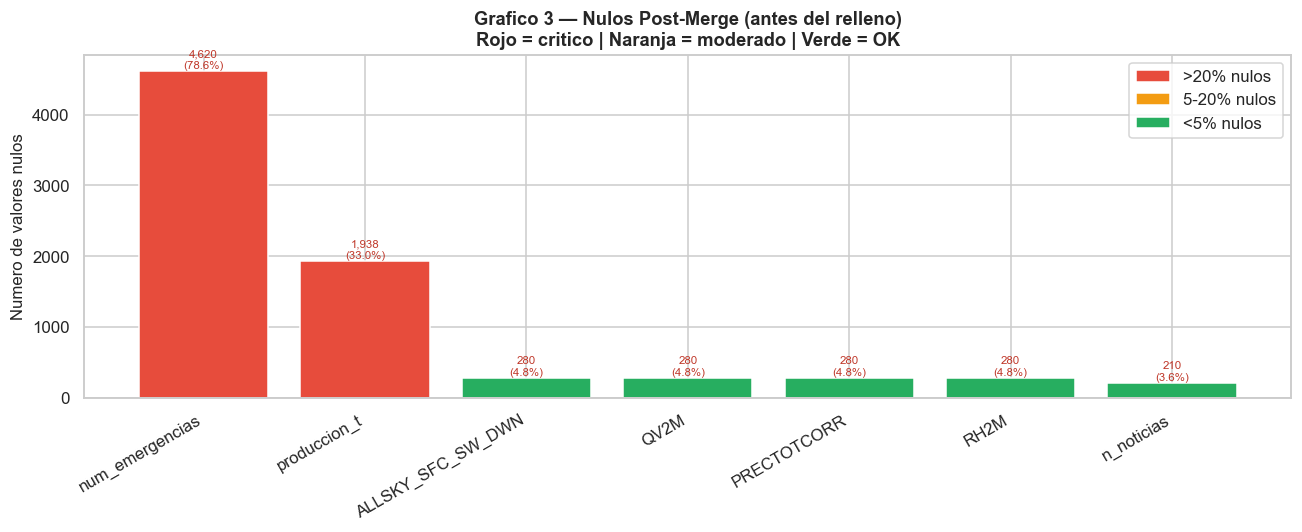

Guardado: pipeline/output/03_eda/act06_g3_nulos_post_merge.png


In [8]:
cols_check = ['produccion_t','num_emergencias','n_noticias'] + VARS_CLIMA[:4]
cols_check = [c for c in cols_check if c in df_int.columns]
nulos_post = df_int[cols_check].isnull().sum().sort_values(ascending=False)
pct_post   = (nulos_post / len(df_int) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
colors_n = ['#e74c3c' if p > 20 else '#f39c12' if p > 5 else '#27ae60'
            for p in pct_post.values]
bars = ax.bar(nulos_post.index, nulos_post.values, color=colors_n, edgecolor='white')
for bar, val, p in zip(bars, nulos_post.values, pct_post.values):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                f'{val:,}\n({p}%)', ha='center', va='bottom', fontsize=7.5, color='#c0392b')
    else:
        ax.text(bar.get_x()+bar.get_width()/2, 5,
                'OK', ha='center', va='bottom', fontsize=8, color='#27ae60')
ax.set_ylabel('Numero de valores nulos', fontsize=11)
ax.set_title('Grafico 3 — Nulos Post-Merge (antes del relleno)\n'
             'Rojo = critico | Naranja = moderado | Verde = OK',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(nulos_post.index, rotation=30, ha='right')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='>20% nulos'),
                   Patch(facecolor='#f39c12', label='5-20% nulos'),
                   Patch(facecolor='#27ae60', label='<5% nulos')])
plt.tight_layout()
g = OUTPUT['eda'] + 'act06_g3_nulos_post_merge.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** Los valores nulos en cada variable despues del merge y antes del relleno. Los nulos en `produccion_t` son meses sin produccion registrada (valor real = 0). Los nulos en variables NASA son provincias sin cobertura climatica.

**Implicacion para el pipeline:** Cada tipo de nulo requiere una estrategia diferente: produccion y emergencias → 0, precio → forward-fill, clima → media de la provincia.

**Implicacion para el modelo:** Los nulos no rellenados correctamente generarian errores en el StandardScaler de la Actividad 9.


---
# 6. Estrategia de Relleno de Nulos Post-Merge

Cada tipo de variable tiene una estrategia de relleno diferente basada en su naturaleza y significado.

| Variable | Estrategia | Justificacion |
|----------|------------|---------------|
| `produccion_t`, `cosecha_ha` | Rellenar con 0 | Ausencia de registro = no hubo produccion |
| `num_emergencias`, `n_noticias` | Rellenar con 0 | Ausencia = no hubo eventos/noticias |
| `precio_chacra_kg` | Forward-fill por provincia | El precio se mantiene hasta el siguiente registro |
| Variables NASA | Media de la provincia | Huecos climaticos se imputan con el promedio historico |


In [9]:
df_int_filled = df_int.copy()

# ── Produccion y cosecha: 0 ───────────────────────────────────────────────
for col in ['produccion_t','cosecha_ha']:
    if col in df_int_filled.columns:
        n_antes = df_int_filled[col].isnull().sum()
        df_int_filled[col] = df_int_filled[col].fillna(0)
        print(f'  {col}: {n_antes:,} nulos → 0')

# ── Emergencias y noticias: 0 ─────────────────────────────────────────────
for col in ['num_emergencias','n_noticias','total_afectados','has_cultivo_perdidas']:
    if col in df_int_filled.columns:
        n_antes = df_int_filled[col].isnull().sum()
        df_int_filled[col] = df_int_filled[col].fillna(0)
        print(f'  {col}: {n_antes:,} nulos → 0')

# ── Precio: forward-fill por provincia ───────────────────────────────────
if 'precio_chacra_kg' in df_int_filled.columns:
    n_antes = df_int_filled['precio_chacra_kg'].isnull().sum()
    df_int_filled = df_int_filled.sort_values(['departamento','provincia','fecha_evento'])
    df_int_filled['precio_chacra_kg'] = (
        df_int_filled.groupby(['departamento','provincia'])['precio_chacra_kg']
        .transform(lambda x: x.ffill().bfill())
    )
    n_despues = df_int_filled['precio_chacra_kg'].isnull().sum()
    print(f'  precio_chacra_kg: {n_antes:,} nulos → {n_despues} (forward-fill)')

# ── Variables NASA: media de la provincia ────────────────────────────────
for col in VARS_CLIMA:
    if col in df_int_filled.columns:
        n_antes = df_int_filled[col].isnull().sum()
        if n_antes > 0:
            df_int_filled[col] = (
                df_int_filled.groupby(['departamento','provincia'])[col]
                .transform(lambda x: x.fillna(x.mean()))
            )
            df_int_filled[col] = df_int_filled[col].fillna(df_int_filled[col].mean())
            n_despues = df_int_filled[col].isnull().sum()
            print(f'  {col}: {n_antes:,} nulos → {n_despues} (media provincia)')

print()
total_nulos_final = df_int_filled.isnull().sum().sum()
print(f'Nulos totales post-relleno: {total_nulos_final}')
if total_nulos_final == 0:
    print('  OK: Dataset completamente sin nulos.')


  produccion_t: 1,938 nulos → 0
  cosecha_ha: 1,938 nulos → 0
  num_emergencias: 4,620 nulos → 0
  n_noticias: 210 nulos → 0
  total_afectados: 4,620 nulos → 0
  precio_chacra_kg: 1,938 nulos → 0 (forward-fill)
  ALLSKY_SFC_SW_DWN: 280 nulos → 0 (media provincia)
  PRECTOTCORR: 280 nulos → 0 (media provincia)


  QV2M: 280 nulos → 0 (media provincia)
  RH2M: 280 nulos → 0 (media provincia)
  T2M: 280 nulos → 0 (media provincia)


  T2M_MAX: 280 nulos → 0 (media provincia)
  T2M_MIN: 280 nulos → 0 (media provincia)
  WS2M: 280 nulos → 0 (media provincia)

Nulos totales post-relleno: 0
  OK: Dataset completamente sin nulos.


### Interpretacion

**Que muestra:** La reduccion de nulos despues de aplicar las estrategias de relleno. El objetivo es llegar a 0 nulos en todas las variables.

**Justificacion de cada estrategia:**
- Produccion = 0: Si no hay registro, no hubo produccion ese mes en esa provincia.
- Precio forward-fill: El precio del limon no cambia abruptamente entre meses; se mantiene el ultimo precio conocido.
- NASA media: Los huecos climaticos son raros y la media historica de la provincia es la mejor estimacion disponible.

**Implicacion para el modelo:** Un dataset sin nulos es el requisito para aplicar el StandardScaler en la Actividad 9 y para que el LSTM-Attention funcione correctamente.


## Grafico 4 — Nulos antes vs despues del relleno


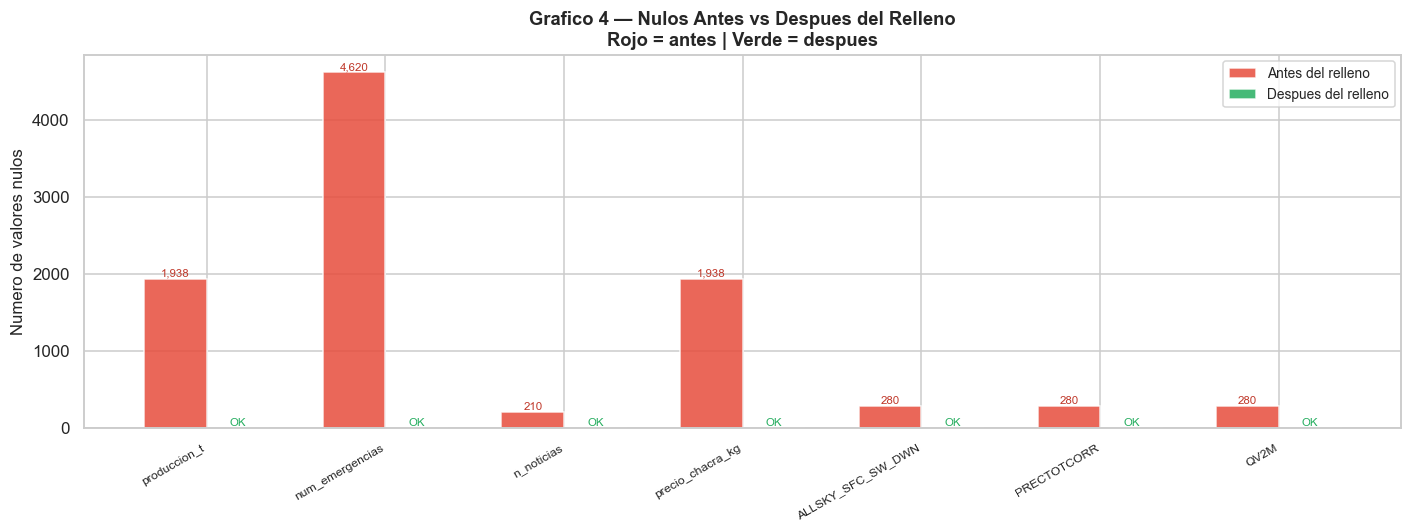

Guardado: pipeline/output/03_eda/act06_g4_nulos_relleno.png


In [10]:
cols_comparar = ['produccion_t','num_emergencias','n_noticias','precio_chacra_kg'] + VARS_CLIMA[:3]
cols_comparar = [c for c in cols_comparar if c in df_int.columns]

nulos_antes  = df_int[cols_comparar].isnull().sum()
nulos_despues = df_int_filled[cols_comparar].isnull().sum()

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(cols_comparar))
width = 0.35
bars1 = ax.bar(x - width/2, nulos_antes.values, width,
               color='#e74c3c', edgecolor='white', label='Antes del relleno', alpha=0.85)
bars2 = ax.bar(x + width/2, nulos_despues.values, width,
               color='#27ae60', edgecolor='white', label='Despues del relleno', alpha=0.85)
for bar, val in zip(bars1, nulos_antes.values):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                f'{val:,}', ha='center', va='bottom', fontsize=7.5, color='#c0392b')
for bar, val in zip(bars2, nulos_despues.values):
    label = str(val) if val > 0 else 'OK'
    color = '#c0392b' if val > 0 else '#27ae60'
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            label, ha='center', va='bottom', fontsize=7.5, color=color)
ax.set_xticks(x)
ax.set_xticklabels(cols_comparar, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Numero de valores nulos', fontsize=11)
ax.set_title('Grafico 4 — Nulos Antes vs Despues del Relleno\n'
             'Rojo = antes | Verde = despues',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
g = OUTPUT['eda'] + 'act06_g4_nulos_relleno.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La efectividad del relleno de nulos. Las barras verdes deben ser 0 para confirmar que el relleno fue exitoso.

**Implicacion para el pipeline:** Si alguna barra verde sigue siendo alta, indica que la estrategia de relleno no fue suficiente y debe revisarse.

**Implicacion para el modelo:** Un dataset sin nulos es el prerequisito para el escalado y el entrenamiento del LSTM-Attention.


---
# 7. Validacion del Dataset Integrado


In [11]:
print('=== VALIDACION DEL DATASET INTEGRADO ===')
print()

# 1. Verificar shape esperado
print(f'Shape esperado: ({n_esperado:,}, N columnas)')
print(f'Shape real:     {df_int_filled.shape}')
if len(df_int_filled) == n_esperado:
    print('  OK: Numero de filas correcto.')
else:
    print(f'  DIFERENCIA: {len(df_int_filled) - n_esperado:,} filas')

# 2. Verificar duplicados
dupes_final = df_int_filled.duplicated(subset=['fecha_evento','departamento','provincia']).sum()
print(f'\nDuplicados en llave maestra: {dupes_final}')
print('  OK: Sin duplicados.' if dupes_final == 0 else '  ALERTA: Hay duplicados.')

# 3. Verificar nulos
nulos_total = df_int_filled.isnull().sum().sum()
print(f'\nNulos totales: {nulos_total}')
print('  OK: Sin nulos.' if nulos_total == 0 else f'  ALERTA: {nulos_total} nulos residuales.')

# 4. Verificar totales de produccion
prod_original = df_midagri['produccion_t'].sum()
prod_integrado = df_int_filled['produccion_t'].sum()
diferencia_pct = abs(prod_original - prod_integrado) / prod_original * 100
print(f'\nProduccion total MIDAGRI original: {prod_original:,.0f} t')
print(f'Produccion total dataset integrado: {prod_integrado:,.0f} t')
print(f'Diferencia: {diferencia_pct:.2f}%')
print('  OK: Produccion conservada.' if diferencia_pct < 1 else '  REVISAR: Diferencia > 1%.')

# 5. Rango temporal
print(f'\nRango temporal: {df_int_filled["fecha_evento"].min()} -> {df_int_filled["fecha_evento"].max()}')
print(f'Meses: {df_int_filled["fecha_evento"].nunique()}')
print(f'Departamentos: {df_int_filled["departamento"].nunique()}')
print(f'Provincias: {df_int_filled["provincia"].nunique()}')
print(f'Columnas: {df_int_filled.columns.tolist()}')


=== VALIDACION DEL DATASET INTEGRADO ===

Shape esperado: (5,880, N columnas)
Shape real:     (5880, 17)
  OK: Numero de filas correcto.

Duplicados en llave maestra: 0
  OK: Sin duplicados.

Nulos totales: 0
  OK: Sin nulos.

Produccion total MIDAGRI original: 100,445 t
Produccion total dataset integrado: 100,445 t
Diferencia: 0.00%
  OK: Produccion conservada.

Rango temporal: 2021-01 -> 2025-08
Meses: 56
Departamentos: 23
Provincias: 105
Columnas: ['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M', 'n_noticias']


## Grafico 5 — Cobertura real del dataset integrado


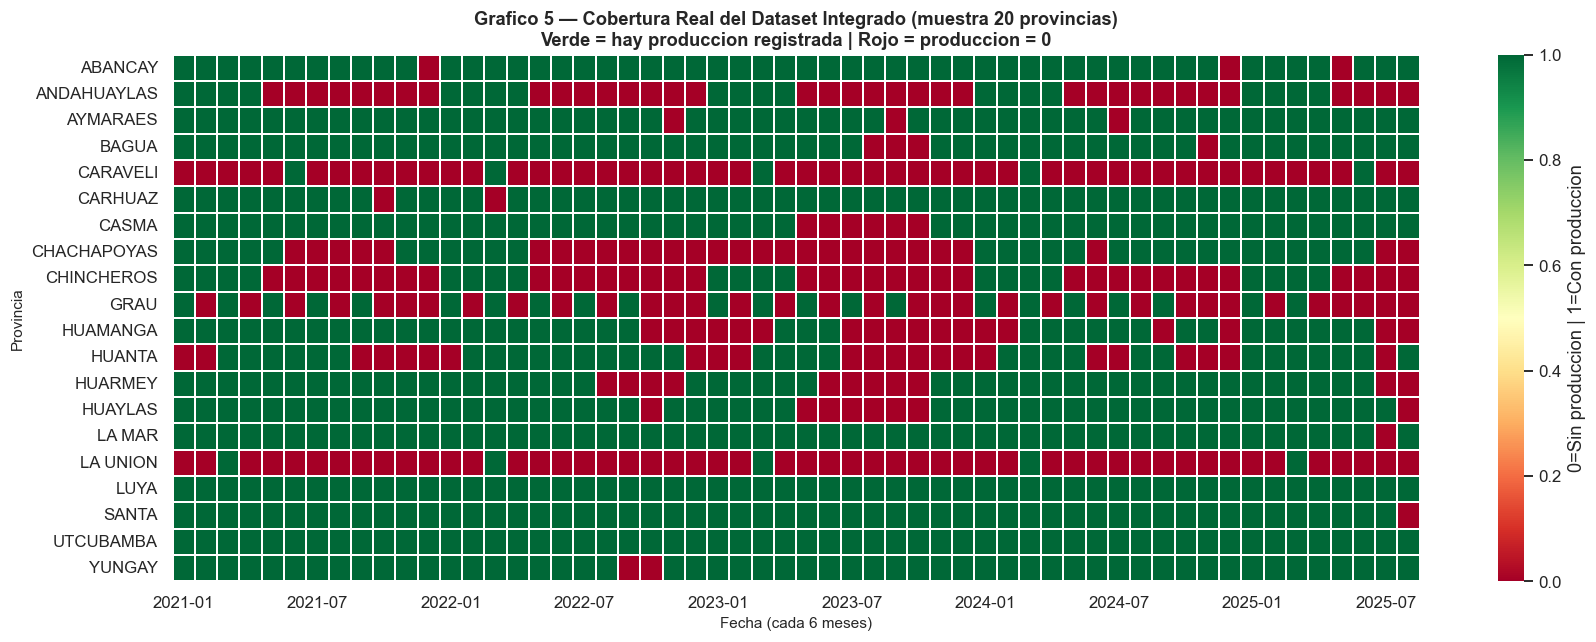

Guardado: pipeline/output/03_eda/act06_g5_cobertura_real.png


In [12]:
# Heatmap de cobertura real (produccion > 0)
prov_sample = df_int_filled['provincia'].unique()[:20]
df_sample = df_int_filled[df_int_filled['provincia'].isin(prov_sample)]
pivot_real = df_sample.pivot_table(
    index='provincia', columns='fecha_evento',
    values='produccion_t', aggfunc='sum', fill_value=0
)
pivot_bool = (pivot_real > 0).astype(int)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_bool, cmap='RdYlGn', ax=ax,
            xticklabels=6, linewidths=0.1,
            cbar_kws={'label': '0=Sin produccion | 1=Con produccion'})
ax.set_title('Grafico 5 — Cobertura Real del Dataset Integrado (muestra 20 provincias)\n'
             'Verde = hay produccion registrada | Rojo = produccion = 0',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fecha (cada 6 meses)', fontsize=10)
ax.set_ylabel('Provincia', fontsize=10)
plt.tight_layout()
g = OUTPUT['eda'] + 'act06_g5_cobertura_real.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La cobertura real de produccion en el dataset integrado. Las celdas rojas son meses donde la produccion fue 0 (no hubo registro en MIDAGRI). Las celdas verdes son meses con produccion registrada.

**Implicacion para el pipeline:** Un patron de celdas rojas concentradas en ciertos meses confirma la estacionalidad de la produccion. Si hay provincias con muchas celdas rojas, pueden ser candidatas a exclusion del modelo.

**Implicacion para el modelo:** Las series temporales con muchos ceros pueden dificultar el aprendizaje del LSTM-Attention. Se evaluara en la Actividad 9 si se filtran las provincias con baja produccion.


## Grafico 6 — Serie temporal de produccion: integrado vs MIDAGRI original


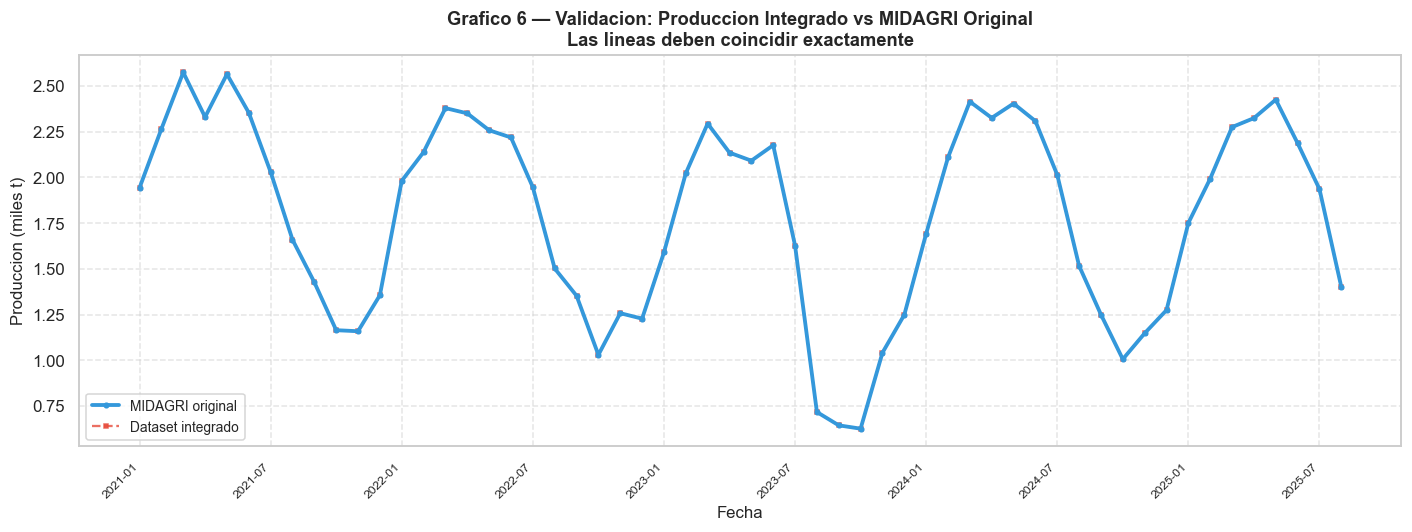

Guardado: pipeline/output/03_eda/act06_g6_validacion_produccion.png
Diferencia maxima entre series: 0.00 t
OK: Las series coinciden.


In [13]:
serie_integrado = df_int_filled.groupby('fecha_evento')['produccion_t'].sum().reset_index()
serie_midagri   = df_midagri.groupby('fecha_evento')['produccion_t'].sum().reset_index()

df_comp = pd.merge(serie_integrado, serie_midagri,
                   on='fecha_evento', suffixes=('_integrado','_original'))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(range(len(df_comp)), df_comp['produccion_t_original']/1e3,
        color='#3498db', linewidth=2.5, marker='o', markersize=3,
        label='MIDAGRI original', zorder=3)
ax.plot(range(len(df_comp)), df_comp['produccion_t_integrado']/1e3,
        color='#e74c3c', linewidth=1.5, linestyle='--', marker='s', markersize=2,
        label='Dataset integrado', zorder=2, alpha=0.8)
ax.set_xticks(range(0, len(df_comp), 6))
ax.set_xticklabels(df_comp['fecha_evento'].iloc[::6], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Produccion (miles t)', fontsize=11)
ax.set_title('Grafico 6 — Validacion: Produccion Integrado vs MIDAGRI Original\n'
             'Las lineas deben coincidir exactamente',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
g = OUTPUT['eda'] + 'act06_g6_validacion_produccion.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)

# Calcular diferencia maxima
diff_max = (df_comp['produccion_t_integrado'] - df_comp['produccion_t_original']).abs().max()
print(f'Diferencia maxima entre series: {diff_max:.2f} t')
print('OK: Las series coinciden.' if diff_max < 1 else 'REVISAR: Hay diferencias.')


### Interpretacion

**Que muestra:** La comparacion entre la serie de produccion del dataset integrado y la serie original de MIDAGRI. Si las lineas coinciden exactamente, el merge no distorsiono los datos.

**Validacion critica:** Si hay diferencias entre las series, indica que el merge introdujo duplicados o perdio registros. Esto debe corregirse antes de continuar.

**Implicacion para el modelo:** La variable objetivo del LSTM-Attention debe ser identica a los datos originales de MIDAGRI. Cualquier distorsion en el merge afectaria directamente la calidad del entrenamiento.


## Grafico 7 — Cobertura multimodal: % de filas con todas las fuentes


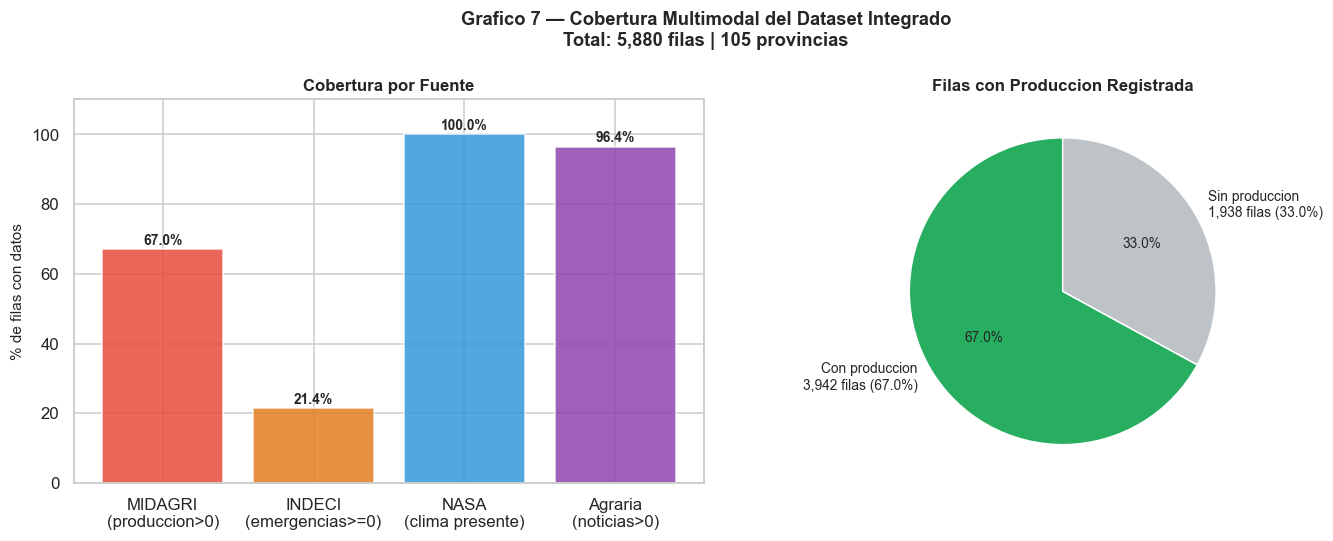

Guardado: pipeline/output/03_eda/act06_g7_cobertura_multimodal.png


In [14]:
# Calcular que porcentaje de filas tiene datos de cada fuente
tiene_midagri = (df_int_filled['produccion_t'] > 0).mean() * 100
tiene_indeci  = (df_int_filled['num_emergencias'] > 0).mean() * 100 if 'num_emergencias' in df_int_filled.columns else 0
tiene_nasa    = df_int_filled[VARS_CLIMA[0]].notna().mean() * 100 if VARS_CLIMA else 0
tiene_agraria = (df_int_filled['n_noticias'] > 0).mean() * 100 if 'n_noticias' in df_int_filled.columns else 0

# Filas con TODAS las fuentes activas
todas = (
    (df_int_filled['produccion_t'] > 0) &
    (df_int_filled.get('num_emergencias', pd.Series([0]*len(df_int_filled))) >= 0) &
    (df_int_filled.get('n_noticias', pd.Series([0]*len(df_int_filled))) >= 0)
).mean() * 100

fuentes = ['MIDAGRI\n(produccion>0)', 'INDECI\n(emergencias>=0)',
           'NASA\n(clima presente)', 'Agraria\n(noticias>0)']
valores = [tiene_midagri, tiene_indeci, tiene_nasa, tiene_agraria]
colores = ['#e74c3c','#e67e22','#3498db','#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras por fuente
bars = axes[0].bar(fuentes, valores, color=colores, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, valores):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('% de filas con datos', fontsize=10)
axes[0].set_ylim(0, 110)
axes[0].set_title('Cobertura por Fuente', fontsize=11, fontweight='bold')

# Pastel de cobertura multimodal
n_total = len(df_int_filled)
n_todas = int(todas * n_total / 100)
axes[1].pie([n_todas, n_total - n_todas],
            labels=[f'Con produccion\n{n_todas:,} filas ({todas:.1f}%)',
                    f'Sin produccion\n{n_total-n_todas:,} filas ({100-todas:.1f}%)'],
            colors=['#27ae60','#bdc3c7'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':9})
axes[1].set_title('Filas con Produccion Registrada', fontsize=11, fontweight='bold')

plt.suptitle('Grafico 7 — Cobertura Multimodal del Dataset Integrado\n'
             f'Total: {n_total:,} filas | {df_int_filled["provincia"].nunique()} provincias',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act06_g7_cobertura_multimodal.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** El porcentaje de filas del dataset integrado que tienen datos de cada fuente. NASA deberia tener cerca del 100% (datos para todas las provincias). MIDAGRI tendra menos del 100% porque no todas las provincias producen limon todos los meses.

**Implicacion para el pipeline:** Las filas sin produccion (produccion_t = 0) son validas y necesarias para mantener la continuidad de las series temporales. El modelo aprendera que ciertos meses tienen produccion 0 en ciertas provincias.

**Implicacion para el modelo:** La cobertura multimodal determina cuantas filas tienen informacion de todas las fuentes simultaneamente, lo que es el conjunto de entrenamiento efectivo del LSTM-Attention.


## Grafico 8 — Correlacion preliminar en el dataset integrado


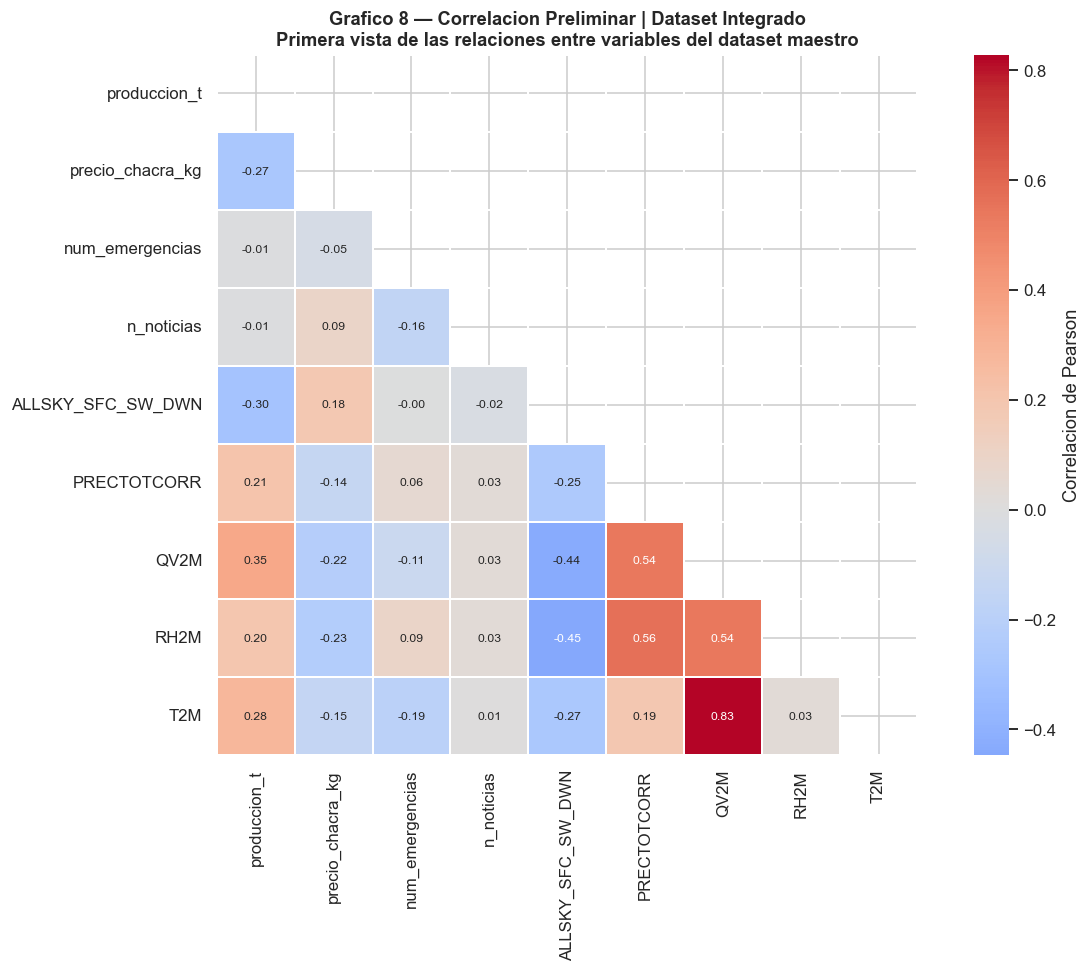

Guardado: pipeline/output/03_eda/act06_g8_correlacion.png

Correlaciones con produccion_t:
  QV2M                      r =   0.354  [MEDIA]
  ALLSKY_SFC_SW_DWN         r =  -0.299  [BAJA]
  T2M                       r =   0.277  [BAJA]
  precio_chacra_kg          r =  -0.273  [BAJA]
  PRECTOTCORR               r =   0.214  [BAJA]
  RH2M                      r =   0.200  [BAJA]
  n_noticias                r =  -0.013  [BAJA]
  num_emergencias           r =  -0.008  [BAJA]


In [15]:
cols_corr = ['produccion_t','precio_chacra_kg','num_emergencias','n_noticias']
if VARS_CLIMA:
    cols_corr += VARS_CLIMA[:5]
cols_corr = [c for c in cols_corr if c in df_int_filled.columns]

corr_int = df_int_filled[cols_corr].corr().round(3)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_int, dtype=bool))
sns.heatmap(corr_int, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, ax=ax,
            cbar_kws={'label': 'Correlacion de Pearson'},
            annot_kws={'size': 8}, linewidths=0.3)
ax.set_title('Grafico 8 — Correlacion Preliminar | Dataset Integrado\n'
             'Primera vista de las relaciones entre variables del dataset maestro',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act06_g8_correlacion.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print()
print('Correlaciones con produccion_t:')
corr_prod = corr_int['produccion_t'].drop('produccion_t').sort_values(key=abs, ascending=False)
for var, r in corr_prod.items():
    nivel = 'ALTA' if abs(r) > 0.5 else 'MEDIA' if abs(r) > 0.3 else 'BAJA'
    print(f'  {var:<25} r = {r:>7.3f}  [{nivel}]')


### Interpretacion

**Que muestra:** La correlacion entre todas las variables del dataset integrado. La primera fila/columna (`produccion_t`) muestra que variables tienen mayor relacion con la produccion de limon en el dataset final.

**Implicacion para el pipeline:** Este heatmap confirma o refuta los hallazgos del EDA de la Actividad 3. Si las correlaciones son similares, el proceso de integracion fue correcto.

**Implicacion para el modelo:** Las variables con alta correlacion con `produccion_t` son las mas valiosas para el LSTM-Attention. Las variables con correlacion cercana a 0 son candidatas a descarte en la Actividad 9.


---
# 8. Exportacion del Dataset Integrado


In [16]:
out_path = OUTPUT['integracion'] + 'dataset_integrado.csv'
df_int_filled.to_csv(out_path, index=False, encoding='utf-8-sig')

print('=' * 70)
print('  ACTIVIDAD 6 COMPLETADA')
print('=' * 70)
print()
print(f'Archivo exportado: {out_path}')
print(f'Shape final: {df_int_filled.shape}')
print(f'Tamano: {os.path.getsize(out_path)//1024} KB')
print()
print('Resumen del dataset integrado:')
print(f'  Filas:         {len(df_int_filled):,}')
print(f'  Columnas:      {len(df_int_filled.columns)}')
print(f'  Rango:         {df_int_filled["fecha_evento"].min()} -> {df_int_filled["fecha_evento"].max()}')
print(f'  Departamentos: {df_int_filled["departamento"].nunique()}')
print(f'  Provincias:    {df_int_filled["provincia"].nunique()}')
print(f'  Nulos totales: {df_int_filled.isnull().sum().sum()}')
print(f'  Duplicados:    {df_int_filled.duplicated(subset=["fecha_evento","departamento","provincia"]).sum()}')
print()
print('Columnas del dataset:')
for i, col in enumerate(df_int_filled.columns):
    print(f'  [{i:02d}] {col}')
print()
print('Proximos pasos:')
print('  Actividad 7 -> Diseno del Star Schema (pipeline/actividad_07_dwh_schema.ipynb)')
print('  Actividad 8 -> Crear esquemas en PostgreSQL')
print('  Actividad 9 -> Pipeline ETL completo')


  ACTIVIDAD 6 COMPLETADA

Archivo exportado: pipeline/output/06_integracion/dataset_integrado.csv
Shape final: (5880, 17)
Tamano: 616 KB

Resumen del dataset integrado:
  Filas:         5,880
  Columnas:      17
  Rango:         2021-01 -> 2025-08
  Departamentos: 23
  Provincias:    105
  Nulos totales: 0
  Duplicados:    0

Columnas del dataset:
  [00] fecha_evento
  [01] departamento
  [02] provincia
  [03] produccion_t
  [04] cosecha_ha
  [05] precio_chacra_kg
  [06] num_emergencias
  [07] total_afectados
  [08] ALLSKY_SFC_SW_DWN
  [09] PRECTOTCORR
  [10] QV2M
  [11] RH2M
  [12] T2M
  [13] T2M_MAX
  [14] T2M_MIN
  [15] WS2M
  [16] n_noticias

Proximos pasos:
  Actividad 7 -> Diseno del Star Schema (pipeline/actividad_07_dwh_schema.ipynb)
  Actividad 8 -> Crear esquemas en PostgreSQL
  Actividad 9 -> Pipeline ETL completo
